In [1]:
# 1. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# 2. Load Dataset

data = fetch_california_housing()

# 3. Creating DataFrame

df = pd.DataFrame(data.data,columns=data.feature_names)
df["target"]=data.target
print(df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  target  
0        -12

In [3]:
# 4.Understand the Dataset

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [4]:
print(df.shape)

(20640, 9)


In [5]:
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


In [6]:
print(df.sample(5))

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
6691   8.4546      46.0  8.537931   1.013793       377.0  2.600000     34.13   
4127   2.2267      25.0  3.244898   1.068027      1412.0  2.401361     34.14   
16205  2.0303      40.0  4.925087   1.141115      2037.0  3.548780     37.94   
8961   4.6932      40.0  4.492424   1.037879       371.0  2.810606     34.02   
14935  4.9792      11.0  6.400826   1.012397      1391.0  2.873967     32.64   

       Longitude   target  
6691     -118.08  5.00001  
4127     -118.21  1.89800  
16205    -121.29  0.63800  
8961     -118.40  3.32800  
14935    -117.00  1.70400  


In [7]:
print(df['target'].value_counts())

target
5.00001    965
1.37500    122
1.62500    117
1.12500    103
1.87500     93
          ... 
0.34200      1
0.46200      1
3.52000      1
3.07900      1
3.85200      1
Name: count, Length: 3842, dtype: int64


In [8]:
print(df['target'].nunique())

3842


In [9]:
print(df['target'].unique())

[4.526 3.585 3.521 ... 4.258 2.007 0.47 ]


In [10]:
print("Statistical Information:")
print(df.describe())

Statistical Information:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude        target  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min    

In [11]:
# 5.Separate Features

X = df.drop("target", axis=1)
y = df["target"]
print("\n X Shape : ", X.shape)
print("y Shape : ", y.shape)


 X Shape :  (20640, 8)
y Shape :  (20640,)


In [12]:
# 6. Split the dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
# 7.Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
# 8. Build ANN regression

model = Sequential([
    Input(shape=(8,)),
    Dense(64,activation="relu"),
    Dropout(0.2),
    Dense(32,activation="relu"),
    Dropout(0.2),
    Dense(1)
])

In [15]:
# 9. Summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# 10. Compile Model

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [17]:
# 11. Creating Early Stopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [18]:
# 12. Train Model

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.3893 - mae: 0.7558 - val_loss: 0.6268 - val_mae: 0.5396
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6824 - mae: 0.5748 - val_loss: 0.4597 - val_mae: 0.4780
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5503 - mae: 0.5257 - val_loss: 0.4339 - val_mae: 0.4584
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4977 - mae: 0.5026 - val_loss: 0.4171 - val_mae: 0.4487
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5096 - mae: 0.4910 - val_loss: 0.4352 - val_mae: 0.4463
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4852 - mae: 0.4840 - val_loss: 0.4043 - val_mae: 0.4387
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4531 - mae: 0.4762 - val_loss: 0.4010 - val_mae: 0.4336
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4225 - mae: 0.4647 - val_loss: 0.3977 - val_mae: 0.4318
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

In [20]:
# 13. Evaluate Model

test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test Loss : ",test_loss)
print("Test MAE : ",test_mae)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step - loss: 0.2793 - mae: 0.3560
Test Loss :  0.2793230712413788
Test MAE :  0.35598063468933105


In [21]:
# 14. Make Predictions

y_pred = model.predict(X_test)
y_pred = y_pred.flatten()
print("\n First 5 predictions : ")
print(y_pred[:5])
print("\n First 5 Actual Values : ")
print(y_test.iloc[:5].values)


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step

 First 5 predictions : 
[0.5770898 1.7270287 4.701954  2.5851898 2.7287574]

 First 5 Actual Values : 
[0.477   0.458   5.00001 2.186   2.78   ]


In [22]:
# 15. Calculate Regression Metrics
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(
    y_test,
    y_pred
)


rmse = np.sqrt(mse)


r2 = r2_score(
    y_test,
    y_pred
)


print("\nMean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R2 Score:", r2)


Mean Absolute Error: 0.35598063354433046
Mean Squared Error: 0.2793230760307008
Root Mean Squared Error: 0.5285102421246922
R2 Score: 0.7868428248975632


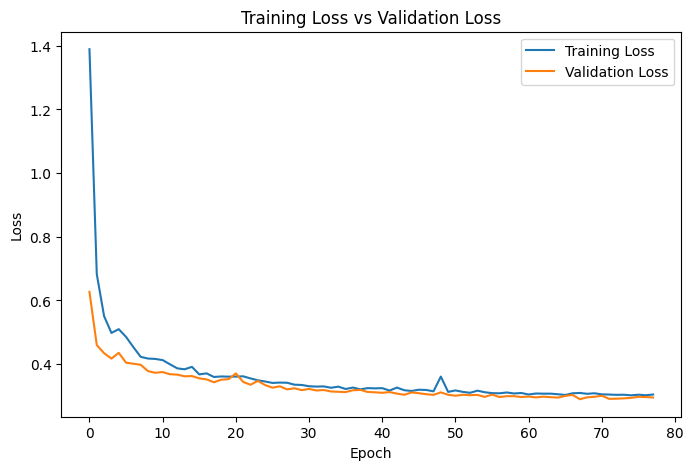

In [26]:
# 16. Training VS Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss vs Validation Loss")

plt.legend()

plt.show()

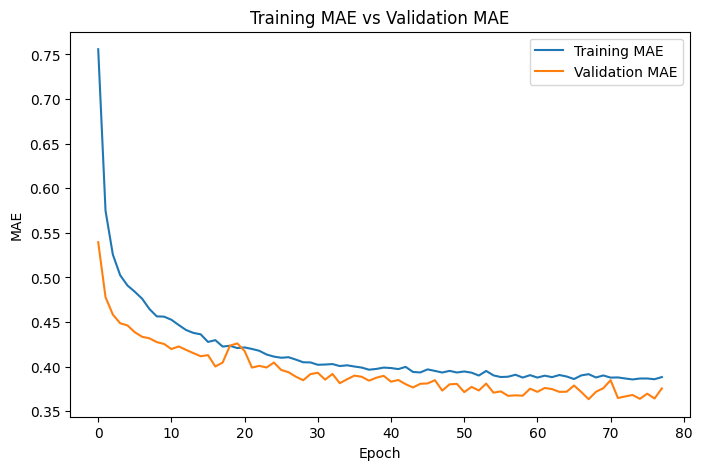

In [29]:
# 17. Training VS Validation MAE
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")

plt.ylabel("MAE")

plt.title("Training MAE vs Validation MAE")

plt.legend()

plt.show()

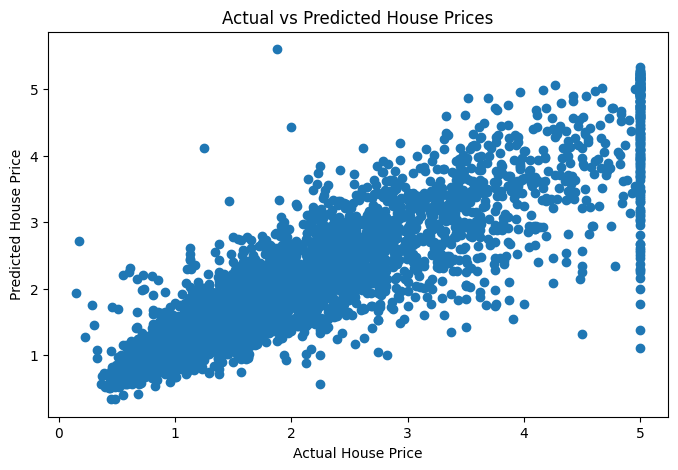

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.show()